# Reservoir release response to inflow intensity

This notebook walks through how a single GDROM v2 reservoir responds
to different inflow scenarios. We pick one reservoir, force it with
four synthetic inflow time series at increasing intensities, and plot
the resulting daily release on a common axis.

The goal is to make the GDROM rule structure tangible. The dispatcher
selects a different module under different combinations of inflow,
storage, drought index, and day of year, and each module computes
release with its own affine or tree-structured rule. Plotting releases
side by side shows the regime transitions explicitly: where the
dispatcher hands off from one module to another, where a module's
internal storage threshold flips a release floor to a release ceiling,
and where the rule simply pegs a constant.

## Setup

The package's public API exposes `load_catalog` for reading a built
catalog. For didactic purposes we also import the reference Python
evaluator (`simulate_release`) from the `evaluator` submodule. The
evaluator is the correctness oracle for the package; T-Route's
production kernel implements the same logic against the catalog's
flat arrays directly, without going through the Python evaluator.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import nwm_gdrom
from nwm_gdrom.evaluator import find_reservoir_index, simulate_release

Load the catalog. The path below assumes the notebook is being run
from `docs/examples/` and a full-CONUS catalog was already built into
`dist/nwm_gdrom_catalog.npz`. To produce the catalog, see the
[quickstart](../quickstart.md).

In [2]:
catalog = nwm_gdrom.load_catalog(Path("../../dist/nwm_gdrom_catalog.npz"))

Loaded 2017 reservoirs from dev


## Picking the reservoir

We want a reservoir whose rule set will show clearly different
behaviour across inflow scenarios. Three properties make that likely:

1. A multi-module dispatcher (so different inputs route to genuinely
   different rules).
2. The dispatcher uses inflow as a discriminating variable somewhere
   (so inflow magnitude matters for which module is picked).
3. The Res_R category, where the rules were trained locally on the
   reservoir's own historical record rather than transferred from an
   analogue.

Hoover Dam (Lake Mead, GRAND_ID 610) fits all three. It has three
modules and a dispatcher tree with thirteen branches that switch on
all four input variables (Inflow, Storage, PDSI, and day of year).
The reservoir has a maximum storage of about 30 million acre-feet on
the Colorado River in Nevada and Arizona, making it the largest
reservoir by volume in the United States.

In [3]:
grand_id = 610
idx = find_reservoir_index(catalog, grand_id)
state = catalog.state[idx].decode().strip()
cap_acre_ft = catalog.storage_cap_m3[idx] / 1233.48

GRAND_ID 610
Category:        Res_R
State:           NV
Capacity:        29.90 million acre-ft
Modules:         3
Has dispatcher:  True


## Synthetic inflow scenarios

We construct four daily inflow time series over a 365-day calendar
year, each with a seasonal sinusoidal envelope but scaled to a
different intensity:

- **Drought**: 25% of the long-term seasonal mean.
- **Low**: 60% of the seasonal mean.
- **Normal**: the seasonal mean directly.
- **High**: 200% of the seasonal mean with a spring flood pulse.

Storage is held constant at 87% of capacity, slightly above the main
dispatcher storage thresholds, so the rule walks have room to switch
modules based on inflow and day of year. PDSI is held at zero
(neutral, no drought signal). Both can be varied independently; see
the discussion at the end of the notebook.

In [4]:
doy = np.arange(1, 366, dtype=float)

# Seasonal envelope: spring snowmelt peak near DOY 91, fall trough near DOY 273.
# Mean = 30,000 acre-ft/day, amplitude = 15,000 acre-ft/day. Phase is chosen
# so day 1 sits cleanly above the winter inflow threshold for the High
# scenario, avoiding a one-day artifact at the start of the calendar year.
seasonal = 30_000 + 15_000 * np.sin(2 * np.pi * doy / 365)

# Smooth flood pulse for the High scenario: a Gaussian bump centered on
# DOY 115 (peak snowmelt), with sigma = 15 days. Peak amplitude is
# 30,000 acre-ft/day, fading smoothly to zero by mid-spring and early
# summer. Using a Gaussian rather than a rectangular pulse avoids the
# step discontinuities that a literal on/off pulse would produce in the
# inflow plot.
flood_pulse = 30_000 * np.exp(-(((doy - 115) / 15) ** 2))

scenarios = {
    "Drought (0.25x mean)": 0.25 * seasonal,
    "Low (0.6x mean)": 0.60 * seasonal,
    "Normal (1.0x mean)": 1.00 * seasonal,
    "High (2.0x + flood)": 2.00 * seasonal + flood_pulse,
}

storage_acre_ft = 0.87 * cap_acre_ft  # ~26 million acre-ft
pdsi = 0.0

Storage held constant at  26,016,434 acre-ft (87.0% of capacity)
PDSI held constant at            0.0


## Simulating releases

For each scenario, we walk the dispatcher and the chosen module for
every day of the year and record the release. The reference evaluator
returns `None` only when the dispatcher's CART finds no matching
branch, which does not happen for Lake Mead in this parameter range,
but we guard against it for portability.

In [5]:
def simulate_year(inflow_series: np.ndarray) -> np.ndarray:
    """Run the GDROM evaluator over one calendar year for the chosen reservoir."""
    out = np.full_like(inflow_series, np.nan)
    for k, (d, q) in enumerate(zip(doy, inflow_series, strict=False)):
        release = simulate_release(
            catalog,
            reservoir_idx=idx,
            inflow=float(q),
            storage=storage_acre_ft,
            pdsi=pdsi,
            doy=float(d),
        )
        if release is not None:
            out[k] = release
    return out


results = {name: simulate_year(q) for name, q in scenarios.items()}

## Plot the forcing and the response

Top panel shows the four synthetic inflow time series. Bottom panel
shows the resulting GDROM release for each. The horizontal step
patterns in the release plot trace out the dispatcher's module
selection: each plateau is a different module, and the heights are
either the module's constant release or one branch of its
storage-conditional rule.

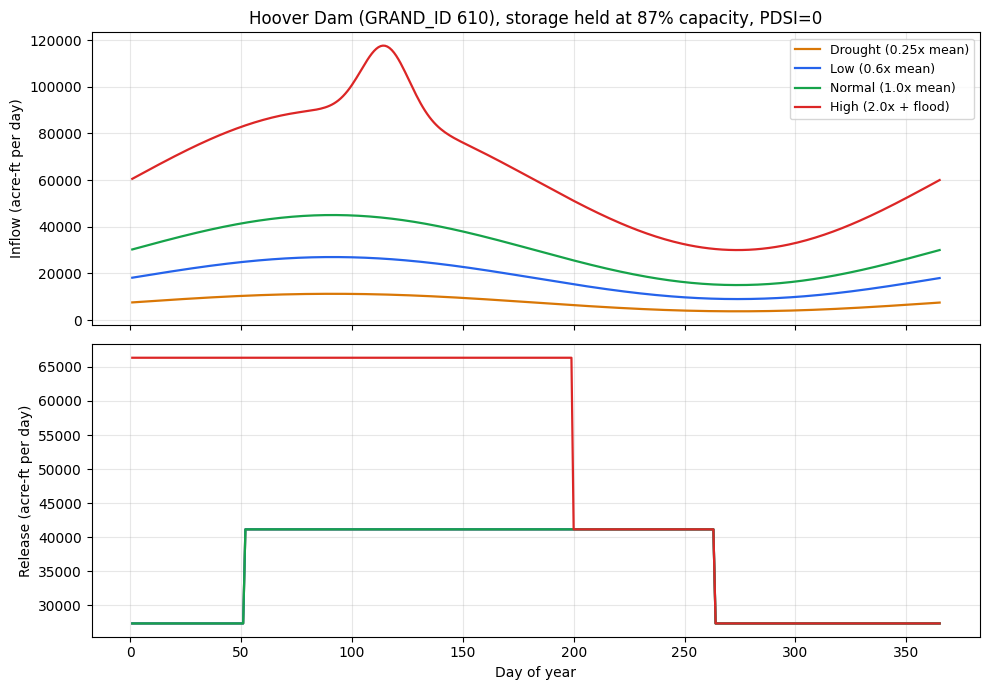

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

palette = ["#d97706", "#2563eb", "#16a34a", "#dc2626"]

for (name, inflow_series), color in zip(scenarios.items(), palette, strict=False):
    axes[0].plot(doy, inflow_series, label=name, color=color, lw=1.6)
    axes[1].plot(doy, results[name], label=name, color=color, lw=1.6)

axes[0].set_ylabel("Inflow (acre-ft per day)")
axes[0].set_title(
    f"Hoover Dam (GRAND_ID {grand_id}), "
    f"storage held at {100 * storage_acre_ft / cap_acre_ft:.0f}% capacity, PDSI=0"
)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=9)

axes[1].set_ylabel("Release (acre-ft per day)")
axes[1].set_xlabel("Day of year")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [7]:
# Thumbnail used by the examples index page. A compact wide version of the
# release plot, with the legend inline so the card reads cleanly at small
# sizes. Not part of the narrative; safe to ignore if you are reading
# the notebook end-to-end.
fig_thumb, ax_thumb = plt.subplots(figsize=(10, 3.4))
for (name, _), color in zip(scenarios.items(), palette, strict=False):
    ax_thumb.plot(doy, results[name], color=color, lw=1.8, label=name)
ax_thumb.set_xlabel("Day of year")
ax_thumb.set_ylabel("Release (acre-ft/day)")
ax_thumb.set_xlim(1, 365)
ax_thumb.grid(alpha=0.3)
ax_thumb.legend(loc="upper right", fontsize=8, ncol=2)
Path("images").mkdir(exist_ok=True)
fig_thumb.savefig("images/release_response_thumb.png", dpi=150, bbox_inches="tight")
plt.close(fig_thumb)

## Reading the response

The release plot reduces to a small number of horizontal plateaus
because Lake Mead's three modules each return one of three discrete
release values at the storage and PDSI we held fixed:

- **Module 0**: a constant 41,164 acre-ft/day.
- **Module 1**: a constant 27,362 acre-ft/day.
- **Module 2**: a storage-conditional rule that returns 17,682 at
  storage below about 25.8 million acre-ft and 66,338 above it. Our
  storage was set at 26.0 million, so module 2 reads as a constant
  66,338 throughout this notebook.

Which of those values the reservoir releases on any given day is
decided entirely by the dispatcher, which splits the year into three
seasons (DOY 1 to 51, 52 to 263, 264 to 365) and uses inflow as an
additional gate inside the first two seasons. With that in mind, the
four curves are easy to read.

**Drought, Low, and Normal scenarios** all stay below both seasonal
inflow thresholds (about 48,000 acre-ft/day in winter, 52,000 in
spring-summer). They share an identical pattern: 27,362 in winter,
41,164 in spring-summer, 27,362 in fall.

**The High scenario** has a noticeably busier curve because it
crosses dispatcher thresholds in both directions:

1. *Days 1 to 51 (winter)*: High inflow stays above 48,000 acre-ft/day,
   so the dispatcher picks module 2 and the release pegs at 66,338.
2. *Days 52 to about 199 (spring-summer, high inflow phase)*: High
   inflow is still above the 52,000 threshold for spring-summer, so
   the dispatcher again routes to module 2 and release stays at 66,338.
3. *Days about 200 to 263 (spring-summer, late season)*: as the
   seasonal envelope falls past the autumn trough, High inflow drops
   below 52,000 acre-ft/day. The dispatcher switches to module 0
   (41,164), and the High curve drops onto the same plateau as the
   Drought, Low, and Normal scenarios.
4. *Days 264 to 365 (fall)*: the dispatcher's fall section branches
   mainly on storage and PDSI rather than inflow, so with storage and
   PDSI fixed every scenario lands on module 1 (27,362). All four
   curves collapse onto a single line.

This is the point of the figure: even a "high inflow" scenario does
not get a uniformly elevated release. The rule is a piecewise lookup
that responds to specific threshold crossings, not a smooth monotonic
function of inflow. Where the dispatcher selects a constant-release
module, the release does not vary with inflow at all.

## What to try next

Any reservoir in the catalog can be substituted by changing
`grand_id` above. Reservoirs to consider:

- `grand_id = 597` (Glen Canyon Dam / Lake Powell, Colorado River),
  four modules, larger and structurally different rule set.
- `grand_id = 753` (Garrison Dam / Lake Sakakawea, Missouri River),
  three modules, a Plains-state reservoir with a different climate
  signature.
- `grand_id = 310` (Grand Coulee, Columbia River), three modules,
  strongly hydropower-driven operating curves.

To exercise the drought signal, set `pdsi` to negative values (try
-2 or -4) and rerun: Lake Mead's fall-season dispatcher branches
on PDSI cutoffs near -0.74 and -0.88, so the fall release will
change discontinuously across those values.

For a more realistic simulation, run a mass-balance loop instead of
holding storage constant: each day, update storage with the net
inflow minus release. This couples the dispatcher state to the
reservoir history and produces release trajectories that are closer
to operational behaviour, at the cost of conflating the rule
response with the storage trajectory.